In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import export_graphviz

In [4]:
churn_df = pd.read_csv('https://s3.amazonaws.com/weclouddata/datasets/random/churn.csv')
churn_df.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
churn_df.columns

Index(['State', 'Account Length', 'Area Code', 'Phone', 'Int'l Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls', 'Churn'],
      dtype='object')

In [6]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           3333 non-null   object 
 1   Account Length  3333 non-null   int64  
 2   Area Code       3333 non-null   int64  
 3   Phone           3333 non-null   object 
 4   Int'l Plan      3333 non-null   object 
 5   VMail Plan      3333 non-null   object 
 6   VMail Message   3333 non-null   int64  
 7   Day Mins        3333 non-null   float64
 8   Day Calls       3333 non-null   int64  
 9   Day Charge      3333 non-null   float64
 10  Eve Mins        3333 non-null   float64
 11  Eve Calls       3333 non-null   int64  
 12  Eve Charge      3333 non-null   float64
 13  Night Mins      3333 non-null   float64
 14  Night Calls     3333 non-null   int64  
 15  Night Charge    3333 non-null   float64
 16  Intl Mins       3333 non-null   float64
 17  Intl Calls      3333 non-null   i

In [9]:
churn_map = {
    True: 1,
    False: 0
}

churn_df['Churn'] = churn_df['Churn'].map(churn_map)

In [11]:
churn_df.value_counts(['Churn'])

Churn
0        2850
1         483
Name: count, dtype: int64

In [12]:
churn_df = churn_df.select_dtypes(include=['int64', 'float64'])
churn_df.head()

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [13]:
import imblearn

In [14]:
y = churn_df['Churn']
X = churn_df.drop(['Churn'], axis=1)

In [16]:
X_train , X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=66, stratify = y)

In [17]:
from collections import Counter 
Counter(y_train)

Counter({0: 2280, 1: 386})

In [18]:
from imblearn.over_sampling import SMOTE

In [20]:
sampler = SMOTE()
X_train_samples, y_train_samples = sampler.fit_resample(X_train, y_train)

In [21]:
Counter(y_train_samples)

Counter({0: 2280, 1: 2280})

In [23]:
model = DecisionTreeClassifier()
modelSMOTE = DecisionTreeClassifier()

In [25]:
model.fit(X_train, y_train)


DecisionTreeClassifier()

In [26]:
y_pred = model.predict(X_test)

In [31]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       570
           1       0.61      0.57      0.59        97

    accuracy                           0.88       667
   macro avg       0.77      0.75      0.76       667
weighted avg       0.88      0.88      0.88       667



In [28]:
modelSMOTE.fit(X_train_samples, y_train_samples)

DecisionTreeClassifier()

In [29]:
y_pred_SMOTE = modelSMOTE.predict(X_test)

In [32]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_SMOTE))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       570
           1       0.40      0.71      0.51        97

    accuracy                           0.80       667
   macro avg       0.67      0.76      0.69       667
weighted avg       0.86      0.80      0.82       667



In [33]:
feature_imp = modelSMOTE.feature_importances_
feature_imp

array([0.06308958, 0.06216742, 0.06088827, 0.19886928, 0.04499402,
       0.03992678, 0.0512912 , 0.03922934, 0.05407036, 0.03850472,
       0.04082144, 0.03715332, 0.03613287, 0.05234906, 0.05775804,
       0.1227543 ])

In [35]:
X_train_samples.columns

Index(['Account Length', 'Area Code', 'VMail Message', 'Day Mins', 'Day Calls',
       'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins',
       'Night Calls', 'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls'],
      dtype='object')

In [41]:
feature_importances = pd.DataFrame({'feature':X_train_samples.columns, 'importance': feature_imp * 100})

In [42]:
feature_importances

,feature,importance
0,Account Length,6.308958
1,Area Code,6.216742
2,VMail Message,6.088827
3,Day Mins,19.886928
4,Day Calls,4.499402
5,Day Charge,3.992678
6,Eve Mins,5.129120
7,Eve Calls,3.922934
8,Eve Charge,5.407036
9,Night Mins,3.850472


In [44]:
sorted_val = feature_importances.sort_values(by='importance', ascending=False)

In [45]:
sorted_val

,feature,importance
3,Day Mins,19.886928
15,CustServ Calls,12.275430
0,Account Length,6.308958
1,Area Code,6.216742
2,VMail Message,6.088827
14,Intl Charge,5.775804
8,Eve Charge,5.407036
13,Intl Calls,5.234906
6,Eve Mins,5.129120
4,Day Calls,4.499402


In [46]:
import seaborn as sns

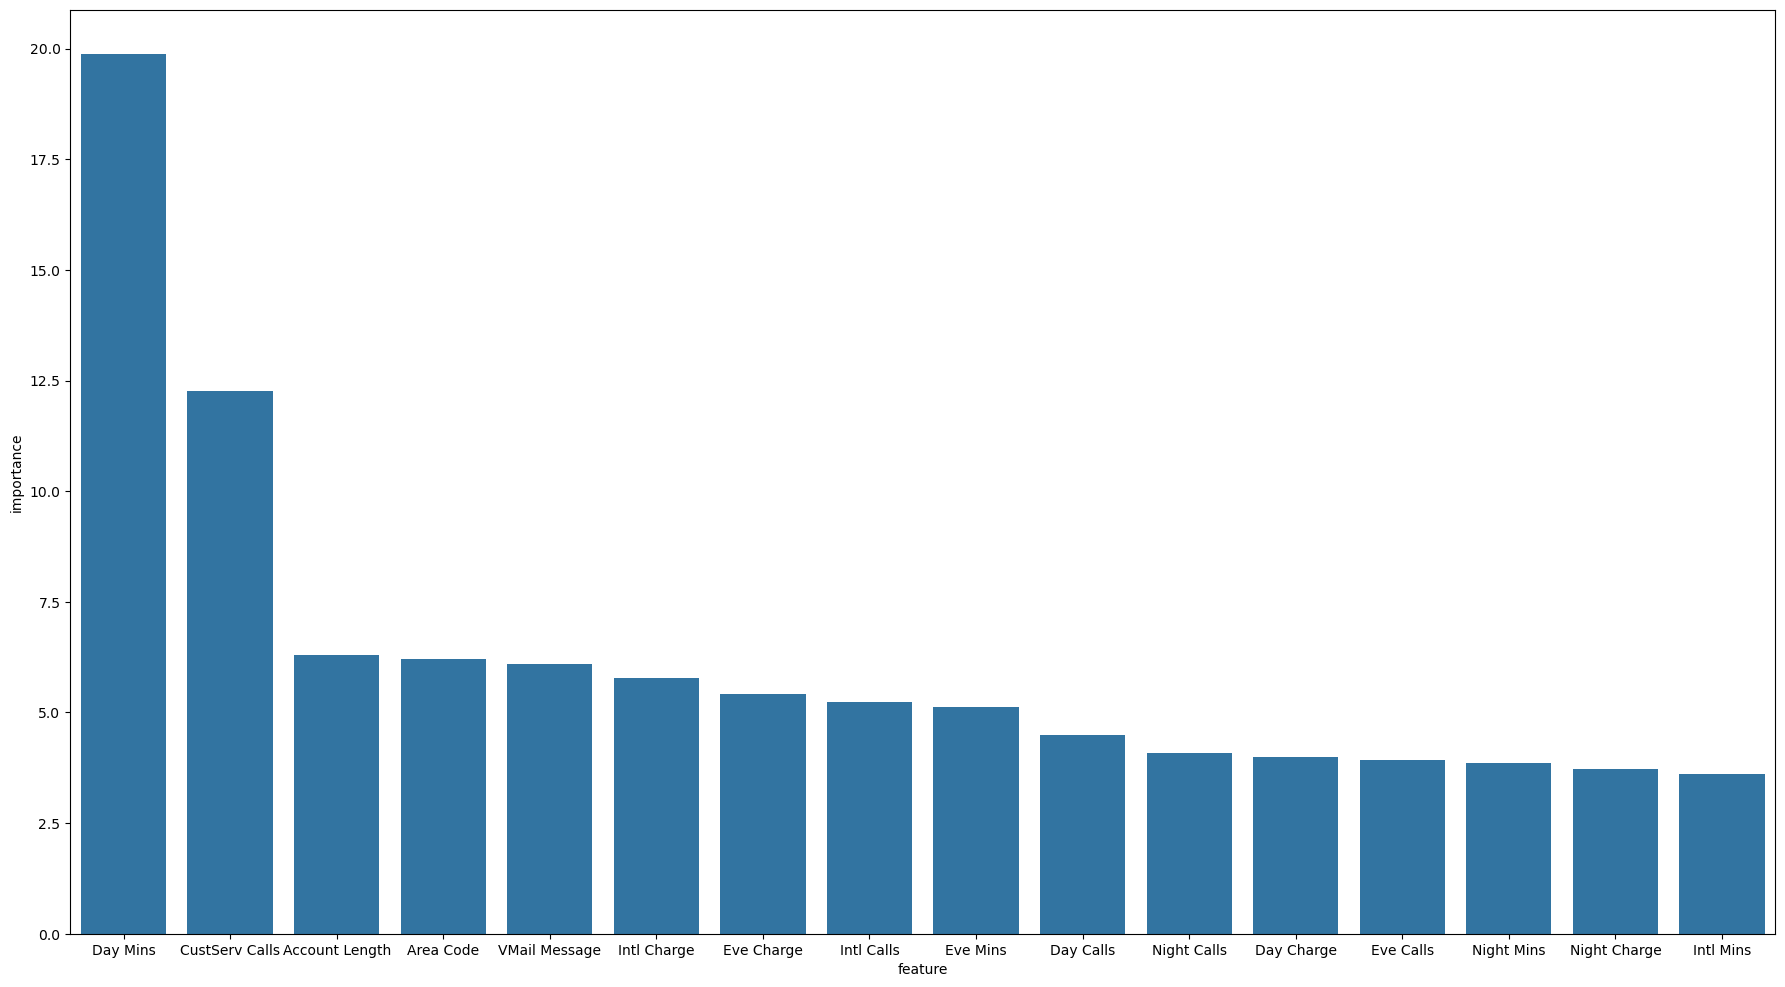

In [50]:
plt.figure(figsize=(22,12))
sns.barplot(sorted_val, x = 'feature' , y= 'importance')
plt.show()